#### Seasonal Dummies and Granger Causality

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2, f
from statsmodels.tsa.vector_ar.var_model import *


"""
import the following functions from your master file.

You will need your OWN companion and stability functions here!
"""

from Smaster1 import (jcitestexog, VARlsExog, sdummy, stabVAR, vec, companion, stabVAR)

np.random.seed(2)

# Parameters
N = 1000  # Number of observations
rho1 = np.array([[0.8, 0],  # Autoregressive coefficient for lag 1
                 [0.8, 0]])

rho2 = np.array([[0.2, 0],  # Autoregressive coefficient for lag 1
                 [0.2, 0]])

alpha = np.array([0, 0])  # Mean of the VAR process

sigma = np.array([[1, 0],  # Covariance matrix of white noise
                  [0, 1]])
                  

# Pre-allocate the array for the VAR(2) process
y = np.zeros((2, N))

# Generate white noise
epsilon = np.random.multivariate_normal([0, 0], sigma, N).T

# Generate the VAR(2) process with time trend
for t in range(2, N):
    y[:, t] = alpha + rho1 @ y[:, t-1] + rho2 @ y[:, t-2] + epsilon[:, t]

y = y.T

y_data = {'Series 1':y[:,0],
'Series 2': y[:,1]}



pd.DataFrame?

y_data = pd.DataFrame(y_data)





**1).** Plot both time series in "y" in a single plot. Does the time series seem to follow each other? Does the model look stable?

How can we know for sure that the two variables follow each other based on the way we created the VAR-model above?

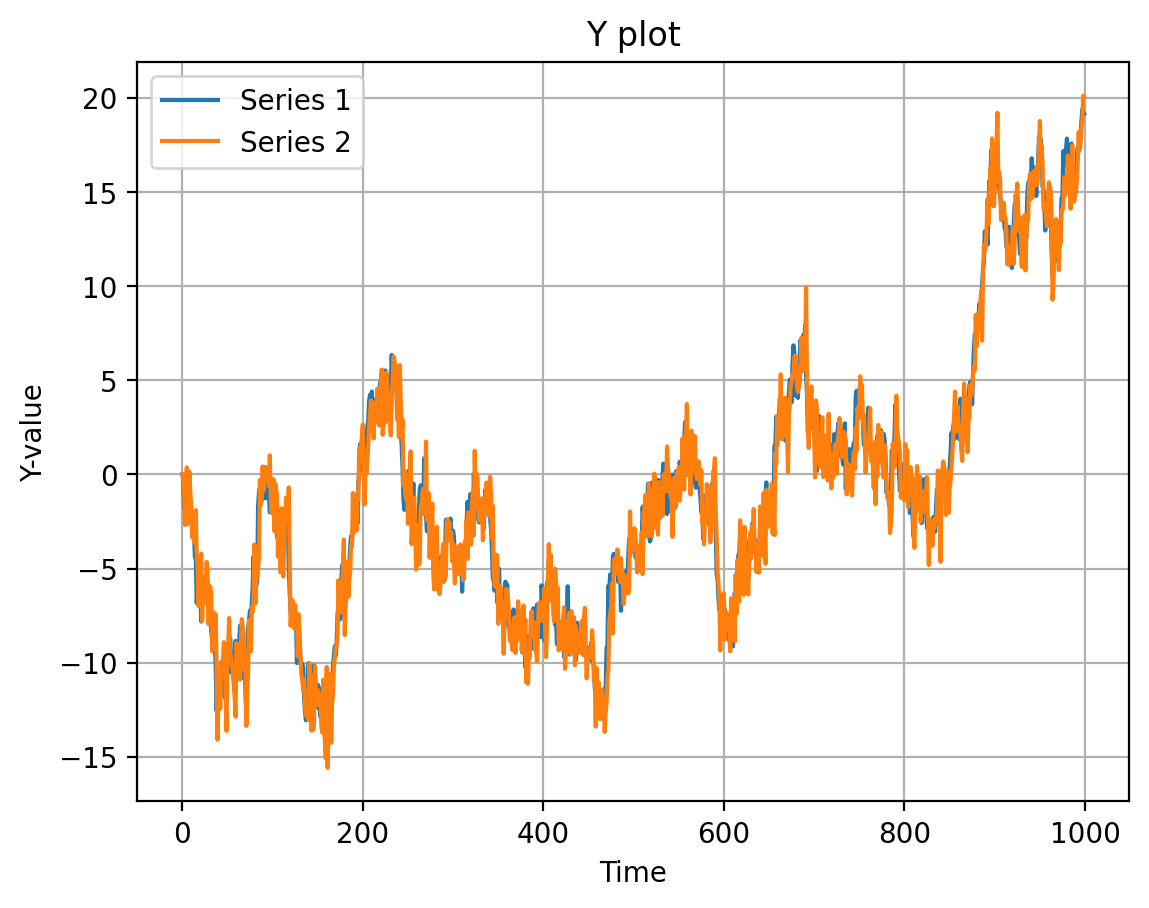

In [98]:
plt.clf()

plt.plot(y_data)
plt.legend(y_data)
plt.xlabel("Time")
plt.ylabel("Y-value")
plt.title("Y plot")
plt.grid()
plt.show()

**2).** Estimate the VAR(2) process with seasonal dummies and a constant. Assume a frequency of 4.

Take a look at the sdummy-function in the master-file to get a sense of what it is doing. It uses the %-operator, which is quite cool.


Are the seasonal dummies significant?

In [80]:
#we specify our model settings
t, K = y.shape

p = 2
con = 1
tr = 0

freq=4
exog = sdummy(t - p, freq)

print(exog)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]


In [81]:
try:
    Beta, CovBeta, tratioBeta, residuals, X, SIGMA = VARlsExog(y, p, con, tr, exog)
except Exception as e:
    print("Error:", e)
    print("The seasonal dummies cause multicollinearity because of no seasonal patterns in the data. Now, try without exog.")
    exog = 0



If the matrix is singular and returns and error: You have reached the right conclusion.

**2).**  Now we try without the dummies, but still with the constant


In [82]:
exog = 0

Beta, CovBeta, tratioBeta, residuals, X, SIGMA = VARlsExog(y, p, con, tr, exog)

Beta

array([[ 0.81385673,  0.77597035],
       [ 0.04560054, -0.00435593],
       [ 0.14867786,  0.25043277],
       [-0.01149997, -0.02093253],
       [ 0.02179429, -0.08165848]])

The correct Beta-matrix should be:

array([[ 0.81385673,  0.77597035],
       [ 0.04560054, -0.00435593],
       [ 0.14867786,  0.25043277],
       [-0.01149997, -0.02093253],
       [ 0.02179429, -0.08165848]])

Proceed without seasonal dummies, without a constant and without a trend.

**3).** Use the same functions from exercise 3 to check stability. Is the model stable? 

In [83]:
exog = 0
con = 0
tr = 0
p=2


Beta, CovBeta, tratioBeta, residuals, X, SIGMA = VARlsExog(y, p, con, tr, exog)

def comp(Beta, p):

    # Antal endogene variable
    A = Beta.shape[1]

    # Companion matrix
    K = np.zeros((A*p, A*p))

    # VAR-koefficienter
    K[:A, :] = Beta[:A*p, :].T

    # Identity matrix under første blok
    if p > 1:
        K[A:, :-A] = np.eye(A * (p - 1))

    return A, K


# Lav companion matrix
n_variables, companion_matrix = comp(Beta, p)

print("Antal variable:", n_variables)
print("Companion matrix:")
print(companion_matrix)


A ,b = comp(Beta, p)


# Then we need to write a function to retrieve the eigenvalues and check the
# stability using the companion matrix.

def stabVAR(A):

    eigenvalues = np.linalg.eigvals(A)

    return eigenvalues


e = stabVAR(companion_matrix)

print("Eigenvalues:")
print(e)
print(f"The sorted eigenvalues are: {e}")

if e[0] < 1:
    print("The VAR is stable")
else:
    print("The VAR is not stable")

Antal variable: 2
Companion matrix:
[[ 0.81442805  0.04403769  0.15040798 -0.01270162]
 [ 0.77382974  0.00149974  0.2439504  -0.01643022]
 [ 1.          0.          0.          0.        ]
 [ 0.          1.          0.          0.        ]]
Eigenvalues:
[ 0.9968203 +0.j          0.03127902+0.j         -0.10608576+0.09415762j -0.10608576-0.09415762j]
The sorted eigenvalues are: [ 0.9968203 +0.j          0.03127902+0.j         -0.10608576+0.09415762j -0.10608576-0.09415762j]
The VAR is stable


Use the functions you made last week to make the companion matrix and get the eigenvalues of that matrix to test the stability.
Change the name of the functions below to match yours.

In [84]:

A = companion(Beta,2)
e = stabVAR(A)

e

array([ 0.9968203 +0.j        ,  0.03127902+0.j        , -0.10608576+0.09415762j, -0.10608576-0.09415762j])

#### Granger causality test

Consider the following VAR(2) model written up equation by equation:

\begin{align*}
y_{1,t} &= c_1 + \phi_{11,1} y_{1,t-1} + \phi_{12,1} y_{2,t-1} + \phi_{11,2} y_{1,t-2} + \phi_{12,2} y_{2,t-2} + \epsilon_{1,t} \\
y_{2,t} &= c_2 + \phi_{21,1} y_{1,t-1} + \phi_{22,1} y_{2,t-1} + \phi_{21,2} y_{1,t-2} + \phi_{22,2} y_{2,t-2} + \epsilon_{2,t}
\end{align*}

To test whether $y_2$ does not Granger-cause $y_1$, the null hypothesis is:

\begin{equation*}
H_0: \phi_{12,1} = \phi_{12,2} = 0
\end{equation*}

The coefficients of the lagged values of $y_2$ in the equation for $y_{1,t}$ are zero. This means that past values of $y_2$ do not provide any statistically significant information for predicting $y_{1,t}$ beyond what is already explained by past values of $y_1$ alone.

Similarly, to test whether $y_1$ does not Granger-cause $y_2$, the null hypothesis is:

\begin{equation*}
H_0: \phi_{21,1} = \phi_{21,2} = 0
\end{equation*}

The coefficients of the lagged values of $y_1$ in the equation for $y_{2,t}$ are zero. This indicates that past values of $y_1$ do not provide any statistically significant information for predicting $y_{2,t}$ beyond what is already explained by past values of $y_2$ alone.

**4).** Use the code below (modefied to also include constant, trends and exogenoues variables) to test for Granger Causality. Which variable Granger Causes which variable?

In [85]:
#this can also be imported from the master file
def vec(y):
  """
  Based on Lutz Kilian's Matlab code
  This function vectorizes an (a x b) matrix y.  The resulting vector vecy
  has dimension (a*b x 1).
  Michael Bergman 2023
  """
  [row,column]=y.shape
  vecy=y.reshape(row*column,1);
  return vecy

In [86]:
from statsmodels.tsa.stattools import grangercausalitytests
grangercausalitytests(y, maxlag=2)


{np.int64(1): ({'ssr_ftest': (np.float64(25.78438920803575),
    np.float64(4.55520753312986e-07),
    np.float64(996.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(25.86205303095152),
    np.float64(3.6670769480709273e-07),
    np.int64(1)),
   'lrtest': (np.float64(25.5329629366438),
    np.float64(4.3488919975327646e-07),
    np.int64(1)),
   'params_ftest': (np.float64(25.784389208035783),
    np.float64(4.55520753312986e-07),
    np.float64(996.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.097354329569711),
    np.float64(0.3341573002022577),
    np.float64(993.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(2.20575955873227),
    np.float64(0.33191386736710876),
    np.int64(2)),
   'lrtest': (np.float64(2.2033255816827477),
    np.float64(0.33231804862699643),
    np.int64(2)),
   'params_ftest': (np.float64(1.097354329569658),
    np.float64(0.33415730020228734),
    np.float64(993.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],

In [87]:

def GC_test(Beta, CovBeta, p, K, con, tr, t):

   varbeta = CovBeta

   bhat = vec(Beta)


   if isinstance(exog, int):
      exog_col = 0
   else:
      exog_len, exog_col = exog.shape


   R1 = np.zeros([p,K*K*p+K*con+K*tr+K*exog_col])

   for i in range(0, p):
      R1[i,i*(K*2)+K] = 1

   # GC from variable 1 on variable 2

   R2 = np.zeros([p,K*K*p+K*con+K*tr+K*exog_col])

   for i in range(0, p):
      R2[i,i*(K*2)+K - 1] = 1


   # Then we can compute the test statistics.
   # Note that the LR chi2 test reported above is not the same as
   # the Wald test.   

   Q1 = ((-R1 @ bhat).T @ np.linalg.inv((R1 @ varbeta) @ R1.T)) @ (-R1 @ bhat)
   pvalQ1 = 1 - chi2.cdf(Q1,p)
   Q1F = Q1/p
   dgf = (t - p)-K*p-1
   pvalQ1F = 1 - f.cdf(Q1F,p,dgf)

   Q2 = ((-R2 @ bhat).T @ np.linalg.inv((R2 @ varbeta) @ R2.T)) @ (-R2 @ bhat)
   pvalQ2 = 1 - chi2.cdf(Q2,p)
   Q2F = Q2/p
   dgf = (t - p)-K*p-1
   pvalQ2F = 1 - f.cdf(Q2F,p,dgf)

   print('Results own GC tests')
   print('Testing GC from variable 2 on variable 1')
   print('Wald Chi2 test',Q1,'with p-value',pvalQ1,'with',p,'degrees of freedom')
   print('Wald F test',Q1F,'with p-value',pvalQ1F,'with df_denom',dgf,', df_num',p,'\n')
   print('Testing GC from variable 1 on variable 2')
   print('Wald Chi2 test',Q2,'with p-value',pvalQ2,'with',p,'degrees of freedom')
   print('Wald F test',Q2F,'with p-value',pvalQ2F,'with df_denom',dgf,', df_num',p)

Now, we run the GC-test. Remember that the null is NO GC.

In [88]:
GC_test(Beta, CovBeta, p, K, con, tr, t)

Results own GC tests
Testing GC from variable 2 on variable 1
Wald Chi2 test [[1.01671752]] with p-value [[0.60148195]] with 2 degrees of freedom
Wald F test [[0.50835876]] with p-value [[0.6016384]] with df_denom 993 , df_num 2 

Testing GC from variable 1 on variable 2
Wald Chi2 test [[683.93399083]] with p-value [[0.]] with 2 degrees of freedom
Wald F test [[341.96699542]] with p-value [[1.11022302e-16]] with df_denom 993 , df_num 2


You should get the following results:

Results own GC tests
Testing GC from variable 2 on variable 1
Wald Chi2 test [[1.01671752]] with p-value [[0.60148195]] with 2 degrees of freedom
Wald F test [[0.50835876]] with p-value [[0.6016384]] with df_denom 993 , df_num 2 

Testing GC from variable 1 on variable 2
Wald Chi2 test [[683.93399083]] with p-value [[0.]] with 2 degrees of freedom
Wald F test [[341.96699542]] with p-value [[1.11022302e-16]] with df_denom 993 , df_num 2

#### Cointegration

**5).** Show that the following VAR(2) model:

\begin{equation*}
x_{t}=\rho+A_{1}x_{t-1}+A_{2}x_{t-2}+u_{t}
\end{equation*}

Can be written into a VECM(1):

\begin{equation*}
x_{t}-x_{t-1}=\rho+A_{1}x_{t-1}+A_{2}x_{t-2}+u_{t}-x_{t-1}+A_{2}x_{t-1}-A_{2}x_{t-1}+u_{t}
\end{equation*}

\begin{equation*}
\Delta x_{t}=\rho+(A_{1}+A_{2}-I_{K})x_{t-1}+A_{2}(x_{t-2}-x_{t-1})+u_{t}
\end{equation*}

\begin{equation*}
\Delta x_{t}=\rho+\Pi x_{t-1}+\Gamma_{1}x_{t-1}+u_{t}
\end{equation*}

where $\Pi=-(I_{K}-A_{1}-A_{2})$ and $\Gamma_{1}=-A_{2}$.

What happened to the error term? What does this mean for our misspecification test from earlier? You had to do this on last year's exam!


**6).** If time, show the same for a VAR(p) process:

The residuals are the same in a VAR model for $x_t$ and a VECM. Since only the residuals are used to test the lag length, it does not matter if one uses a VAR or VECM to test the lag length. I set up the following VAR($p$) model, where $p$ is the lag length:

\begin{equation*}
    x_{t}=\rho+A_{1}x_{t-1}+A_{2}x_{t-2}+...+A_{p}x_{t-p}+u_{t}
    \tag*{: VAR(p)}
\end{equation*}

Subtracting $x_{t-1}$ on both sides and using that $-x_{t}-x_{t-1}=\Delta x_{t}$ and $-x_{t-1}=I_{K}x_{t-1}$, I get:

\begin{equation*}
    \Delta x_{t}=\rho-(I_{K}-A_{1})x_{t-1}+A_{2}x_{t-2}+...+A_{p}x_{t-p}+u_{t}
\end{equation*}

Now I add and subtract $A_{2}x_{t-1}$ on the RHS and rewrite $-A_{2}x_{t-1}+A_{2}x_{t-2}=-A_{2}\Delta x_{t-1}$:

\begin{equation*}
    \Delta x_{t}=\rho-(I_{K}-A_{1}-A_{2})x_{t-1}-A_{2}\Delta x_{t-1}+...+A_{p}x_{t-p}+u_{t}
\end{equation*}

Now I add and subtract $A_{3}x_{t-1}$ and $A_{3}x_{t-2}$ on the RHS. Here, I again use that $-A_{3}x_{t-1}+A_{3}x_{t-2}=-A_{3}\Delta x_{t-1}$ and $-A_{3}x_{t-2}+A_{3}x_{t-3}=-A_{3}\Delta x_{t-2}$:

\begin{equation*}
    \Delta x_{t}=\rho-(I_{K}-A_{1}-A_{2}-A_{3})x_{t-1}-(A_{2}+A_{3})\Delta x_{t-1}-A_{3}\Delta x_{t-2}+A_{4}x_{t-4}+...+A_{p}x_{t-p}+u_{t} 
\end{equation*}

Now proceeding by adding and subtracting $A_{i}x_{t-j}$ for $i=4,5,...,p$ and $j=1,2,...,p-1$ results in:

\begin{equation*}
    \Delta x_{t}=\rho+\Pi x_{t-1}+\sum_{i=1}^{p-1}\Gamma_{i}\Delta x_{t-i}+u_{t}   
    \tag*{: VECM(p-1)}
\end{equation*}

where $\Pi=-(I_{K}-A_{1}-...-A_{p})$ and $\Gamma=-(A_{i+1}+...+A_{p})$ for $i=1,2,...,p-1$. This is the VECM representation (exactly the same as equation (2) in the exam questions) and the residuals are still the same. Hence, I get that $u_t = v_t$, and it does not matter if we use a VAR model or VECM to calculate the lag length.

#### The Johansen Test

Remember the five different versions of the VECM model:
  - **Case 1.** 𝜈 = 0 and 𝛿 = 0: No deterministic components implying that all cointegration vectors have mean zero and that the mean of first differences is zero.

    $$
    \Delta y_t = \alpha \beta' y_{t-1} + \sum_{i=1}^{p-1} \Gamma_i \Delta y_{t-i} + \epsilon_t
    $$

  - **Case 2.** 𝜏 = 𝜌 = 𝛾 = 0: Mean of cointegration vectors is 𝜇 and no trends in either levels (𝛾 = 0) or first differences (𝜏 = 0) and variables are stationary around a constant mean.

    $$
    \Delta y_t = \alpha \left( \beta' y_{t-1} + \mu \right) + \sum_{i=1}^{p-1} \Gamma_i \Delta y_{t-i} + \epsilon_t
    $$

  - **Case 3.** 𝜏 = 𝜌 = 0: Unrestricted constant, no quadratic trend in levels, linear trend in levels since 𝛾 ≠ 0 and variables are stationary around a constant mean.

    $$
    \Delta y_t = \alpha \left( \beta' y_{t-1} + \mu \right) + \sum_{i=1}^{p-1} \Gamma_i \Delta y_{t-i} + \gamma + \epsilon_t
    $$

  - **Case 4.** 𝜏 = 0: No quadratic trends in levels, linear trend in levels and variables are trend stationary.

      $$
      \Delta y_t = \alpha \left( \beta' y_{t-1} + \rho t \right) + \sum_{i=1}^{p-1} \Gamma_i \Delta y_{t-i} + \gamma + \epsilon_t
      $$

  - **Case 5.** No restrictions on deterministic components, linear trend in first differences, quadratic trend in levels and variables are trend stationary.

    $$
    \Delta y_t = \alpha \left( \beta' y_{t-1} + \rho t \right) + \sum_{i=1}^{p-1} \Gamma_i \Delta y_{t-i} + \gamma + \tau t + \epsilon_t
    $$

Before we can estimate a VECM, we need to figure out the rank of $\alpha \beta'$, also defined as $\Pi$. To do so, we consider the testing sequence:

$$
H_0(r_0) : \text{rank}(\Pi) = r_0 \quad \text{versus} \quad H_1(r_0) : \text{rank}(\Pi) > r_0, \quad r_0 = 0, \dots, K - 1. \tag{3.3.1}
$$

The corresponding LR test statistic is

$$
LR^{\text{trace}}(r_0) = 2(\log l(r_0) - \log l(K)) = -T \sum_{i=r_0+1}^{K} \log(1 - \lambda_i),
$$

where $l(r)$ denotes the maximum of the Gaussian likelihood function (3.2.9) given the cointegration rank $r$ and $\lambda_i$ is the $i^{\text{th}}$ eigenvalue obtained by the Johansen procedure in Section 3.2.2. This test is often referred to as the trace test. The cointegration rank is identified as the first value where the trace statistic does not reject the null hypothesis.

**7).** Perform the Johansen Cointegration test using Case 3. What is the suggested cointegration rank? Remember to choose the correct number of lags.


In [111]:
model = 3
exog = 0

#notice how we specify VECM lag length
(lr1, cval5, cval10, pval, l, beta, alpha, c0, c1, d0, d1) = jcitestexog(y,p-1,exog, model)


***************************
Johansen Cointegration test
Sample size: 998
Lags in VAR: 2
Lags in Vec: 1
Statistic: Trace
Model: H1 ("ci") [constant in coint vec and linear trend in levels]
  r    stat    cVal5%    cVal10%    p-value    EigVal
---  ------  --------  ---------  ---------  --------
  0   5.686    15.495    13.4295     0.7407    0.0056
  1   0.125     3.842     2.7055     0.7771    0.0001


***************************
ML estimates of beta.T, the cointegration vector
--------  ---------
0.144988  0.0501677
--------  ---------
ML estimates of alpha, the adjustment coefficients
------------
  -0.0736462
-0.000535141
------------
ML estimates of Pi = alpha x beta.T
------------  ------------
  -0.0106778   -0.00369466
-7.75892e-05  -2.68468e-05
------------  ------------

***************************
Deterministic terms
ML estimates of c0
 [1.3651]
ML estimates of c1
 [0.0006 -0.0804]
ML estimates of d0
 [None]
ML estimates of d1
 [None]


**8).** Estimate the model using model 4. Does the results change?

In [103]:
model = 4

(lr1, cval5, cval10, pval, l, beta, alpha, c0, c1, d0, d1) = jcitestexog(y,p-1, exog, model)


***************************
Johansen Cointegration test
Sample size: 998
Lags in VAR: 2
Lags in Vec: 1
Statistic: Trace
Model: H* ("cili") [constant and linear trend in coint vec, linear trend in levels]
  r     stat    cVal5%    cVal10%    p-value    EigVal
---  -------  --------  ---------  ---------  --------
  0  610.791    25.872    23.3427      0.001    0.4535
  1    7.738    12.517    10.6662     0.3125    0.0077


***************************
ML estimates of beta.T, the cointegration vector
--------  -------
-1.14926  1.14429
--------  -------
ML estimates of alpha, the adjustment coefficients
---------
0.0334882
-0.896156
---------
ML estimates of Pi = alpha x beta.T
----------  ---------
-0.0384868  0.0383202
   1.02992   -1.02546
----------  ---------

***************************
Deterministic terms
ML estimates of c0
 [0.0223]
ML estimates of c1
 [0.0227 0.0008]
ML estimates of d0
 [0.0001]
ML estimates of d1
 [None]


**9).** Consider the following VAR(2) process instead where "rho1" and "rho2" have been changed. Plot the time series. Is the model still stable? Perform the cointegration test again. What is the rank now?

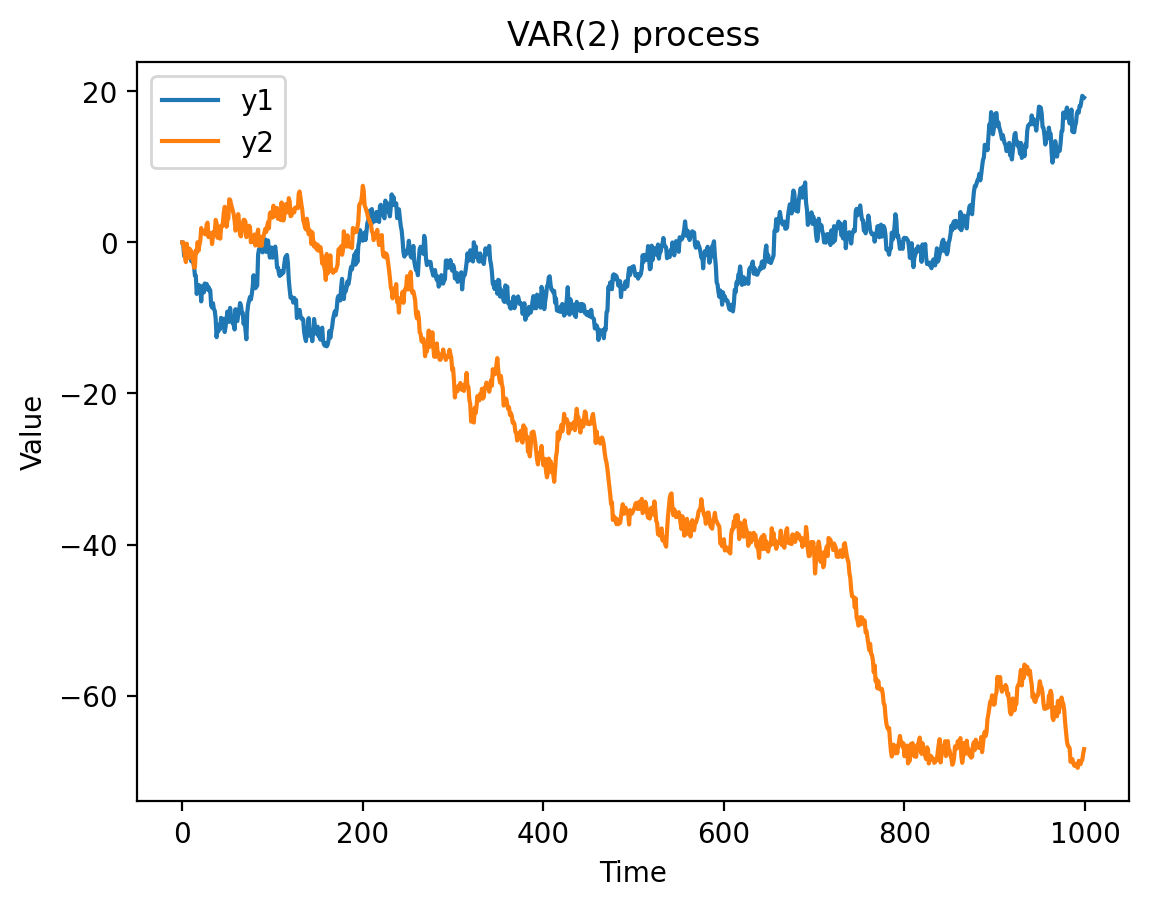

In [104]:
np.random.seed(2)

# Parameters
N = 1000  # Number of observations
rho1 = np.array([[0.8, 0],  # Autoregressive coefficient for lag 1
                 [0, 0.8]])

rho2 = np.array([[0.2, 0],  # Autoregressive coefficient for lag 1
                 [0, 0.2]])

alpha = np.array([0, 0])  # Mean of the VAR process

sigma = np.array([[1, 0],  # Covariance matrix of white noise
                  [0, 1]])
                  

# Pre-allocate the array for the VAR(2) process
y = np.zeros((2, N))

# Generate white noise
epsilon = np.random.multivariate_normal([0, 0], sigma, N).T

# Generate the VAR(1) process with time trend
for t in range(2, N):
    y[:, t] = alpha + rho1 @ y[:, t-1] + rho2 @ y[:, t-2] + epsilon[:, t]

y = y.T

# Plot both time series of the VAR(2) process in a single plot
plt.figure()
plt.plot(y)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('VAR(2) process')
plt.legend(['y1', 'y2'])
plt.show()

In [110]:
Beta, CovBeta, tratioBeta, residuals, X, SIGMA = VARlsExog(y, p, con, tr, exog)

A = companion(Beta,p)
e = stabVAR(A)

e

array([-0.19206421+0.03897854j, -0.19206421-0.03897854j,  0.99644506+0.j        ,  1.00042892+0.j        ])

In [108]:
model = 3

(lr1, cval5, cval10, pval, l, beta, alpha, c0, c1, d0, d1) = jcitestexog(y,p-1,exog,model)


***************************
Johansen Cointegration test
Sample size: 998
Lags in VAR: 2
Lags in Vec: 1
Statistic: Trace
Model: H1 ("ci") [constant in coint vec and linear trend in levels]
  r    stat    cVal5%    cVal10%    p-value    EigVal
---  ------  --------  ---------  ---------  --------
  0   5.686    15.495    13.4295     0.7407    0.0056
  1   0.125     3.842     2.7055     0.7771    0.0001


***************************
ML estimates of beta.T, the cointegration vector
--------  ---------
0.144988  0.0501677
--------  ---------
ML estimates of alpha, the adjustment coefficients
------------
  -0.0736462
-0.000535141
------------
ML estimates of Pi = alpha x beta.T
------------  ------------
  -0.0106778   -0.00369466
-7.75892e-05  -2.68468e-05
------------  ------------

***************************
Deterministic terms
ML estimates of c0
 [1.3651]
ML estimates of c1
 [0.0006 -0.0804]
ML estimates of d0
 [None]
ML estimates of d1
 [None]


In [109]:
model = 4

(lr1, cval5, cval10, pval, l, beta, alpha, c0, c1, d0, d1) = jcitestexog(y,p-1,exog,model)


***************************
Johansen Cointegration test
Sample size: 998
Lags in VAR: 2
Lags in Vec: 1
Statistic: Trace
Model: H* ("cili") [constant and linear trend in coint vec, linear trend in levels]
  r    stat    cVal5%    cVal10%    p-value    EigVal
---  ------  --------  ---------  ---------  --------
  0  19.772    25.872    23.3427     0.2548    0.0161
  1   3.589    12.517    10.6662     0.8003    0.0036


***************************
ML estimates of beta.T, the cointegration vector
---------  --------
-0.170885  0.152651
---------  --------
ML estimates of alpha, the adjustment coefficients
----------
  0.087724
-0.0909282
----------
ML estimates of Pi = alpha x beta.T
----------  ----------
-0.0149907   0.0133911
 0.0155382  -0.0138803
----------  ----------

***************************
Deterministic terms
ML estimates of c0
 [-2.9558]
ML estimates of c1
 [-0.0266 -0.0257]
ML estimates of d0
 [0.0162]
ML estimates of d1
 [None]


**10).** Now answer question 7 in the homework.